# 08 · 예산, 비용, 관측 가능성

**구성요소:** 예산 · 런로그(run log) · 비용 관측 가능성(observability).

**핵심 아이디어**

> 토큰 소진(S1): "청구서가 튄다. 트리아지 결과가 비었거나 노이즈뿐인데도 루프가 서브에이전트 체인을 통째로 돌린다."

기록에 남은 사고 하나 — 루프에 시도 상한이 없었다는 이유만으로 **48시간 동안 약 8M 토큰**이 타 버렸다.

**루프는 운영 업무다.** 앞의 노트북들이 루프를 품질 기계로 다뤘다면, 이 노트북은 같은 루프를 회계 대상으로 다룬다. 그리고 앞선 실행들이 남긴 **실측 데이터**로 세 가지를 한다.

1. 루프 비용 추정기(현실적 믹스 모형)를 재현해 하루 지출을 **미리 예측한다**.
2. 이 프로젝트 자신의 런로그를 읽어 **실제로 쓴 양을 사후에 확인한다**.
3. NB01 의 루프 전략별 실측 토큰 수로 **비용·품질 프런티어**를 세우고, 토큰당 품질을 가장 많이 사 오는 운영점을 찾는다.

세 부분의 순서가 곧 이 노트북의 논리다 — **예측하고, 기록하고, 판정한다.** 셋 중 어느 하나가 빠지면 예산은 숫자가 아니라 희망이 된다.

━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
  실행 환경 (자동 판별)
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
  LLM       : openai    gpt-5.6-luna
              ↳ localhost 무응답 → OPENAI_API_KEY 감지 · 선호 순위표에서 자동 선택 (캐시)
  임베딩    : openai    text-embedding-3-small
              ↳ CUDA 미가용 → API 임베딩 · 기본값 (캐시)
  데이터    : /Users/namuai/06-claude/agentic-loop-engineering/agentic-loop-engineering-course-kr/data
  전환      : LLM_PROVIDER=vllm|openai  /  EMBED_PROVIDER=local|openai
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

========================================= 예산 · 비용 · 관측 가능성 =========================================


*모든 실행은 예산 가드를 통과한 뒤 토큰과 결과를 기록한다*

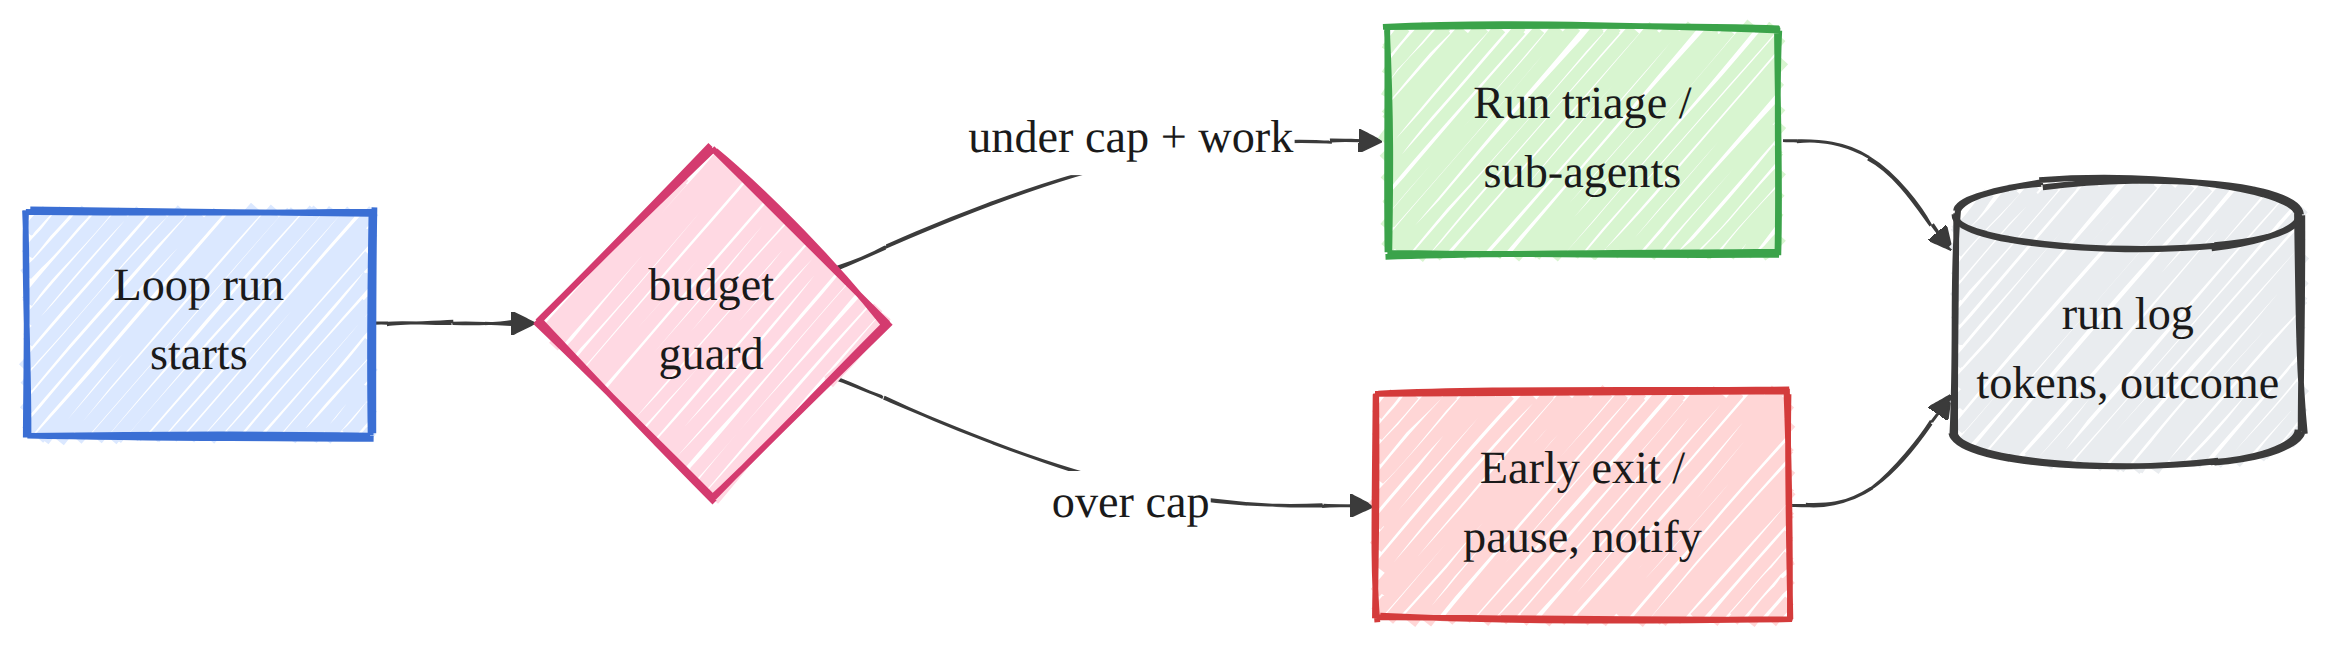

In [1]:
import os
import sys

sys.path.insert(0, os.environ.get("LEN_PROJECT_ROOT", os.path.abspath(".")))

from common import show, plotting, runlog, runtime

# 실행 환경 자동 판별. 이 노트북은 모델을 호출하지 않지만, 어느 백엔드 기준으로
# 비용을 읽어야 하는지가 뒷부분 손익분기 계산의 전제가 되므로 먼저 찍어 둔다.
rt = runtime.bootstrap()

show.head("예산 · 비용 · 관측 가능성")
show.diagram("budget", "모든 실행은 예산 가드를 통과한 뒤 토큰과 결과를 기록한다")

## 1부: 루프 비용 추정기 (현실적 믹스 모형)

주기(cadence)를 하루 실행 횟수로 바꾼다. 그리고 실행 하나는 무작업(no-op), 전체 트리아지, 실제 조치의 **혼합**이며, 그 혼합 비율은 자동화 준비 수준(level)에 달렸다. 여기 쓰인 실행당 토큰 수치는 패턴 레지스트리의 가정값이다. 3부에서 이것을 실측치로 교체한다.


In [2]:
# ── 1부: 루프 비용 추정기 ──────────────────────────────────────────
# 주기 문자열("15m")을 하루 실행 횟수로 바꾸고, 준비 수준별 믹스로 실행당
# 평균 토큰을 낸 뒤 둘을 곱한다. 곱셈의 두 항을 분리해 두는 것이 핵심이다.

INTERVAL_MS = {"m": 60_000, "h": 3_600_000, "d": 86_400_000}


def runs_per_day(interval):
    """'15m' → 96. 하루(86,400,000ms)를 주기로 나눈다."""
    num, unit = int(interval[:-1]), interval[-1]
    return 86_400_000 // (num * INTERVAL_MS[unit])


def cadence_runs(cadence, conservative=False):
    """'5m-15m' 처럼 범위로 적힌 주기를 처리한다.
    기본은 max(=가장 촘촘한 쪽)다. 예산은 낙관이 아니라 최악을 기준으로 잡는다."""
    parts = [p.strip() for p in cadence.split("-")]
    runs = [runs_per_day(p) for p in parts]
    return min(runs) if conservative else max(runs)


def realistic_mix(level, early_exit):
    """(무작업, 보고, 조치) 비율. 조기 종료가 켜지면 무작업 비율이 크게 오른다.

    ⚠️ 함정: 이 비율은 측정치가 아니라 가정이다. 조기 종료를 켜 놓고 실제로는
       루프가 매번 전체 체인을 도는 상황이면, 아래 예측은 실제 청구서의
       절반도 안 되는 낙관치가 된다. 가정한 믹스는 반드시 런로그로 검증한다.
    """
    if level == "L1":
        return (0.9, 0.1, 0.0) if early_exit else (0.6, 0.4, 0.0)
    if level == "L2":
        return (0.85, 0.1, 0.05) if early_exit else (0.5, 0.3, 0.2)
    return (0.4, 0.35, 0.25)


def estimate(pattern, cadence, level, cost, early_exit):
    rpd = cadence_runs(cadence)
    no, rep, act = realistic_mix(level, early_exit)
    # 실행당 비용은 세 종류 비용의 가중 평균이다. 조치 비용이 무작업의 40배이므로
    # 조치 비율이 조금만 올라도 평균이 크게 끌려 올라간다.
    per_run = cost["noop"] * no + cost["report"] * rep + cost["action"] * act
    return {"pattern": pattern, "cadence": cadence, "level": level, "runs_per_day": rpd,
            "tokens_per_run": int(per_run), "tokens_per_day": int(per_run * rpd)}


# 패턴별 비용 수치 (무작업 / 보고 / 조치 토큰 비용)와 조기 종료 사용 여부
REG = {
    "daily-triage": ({"noop": 5000, "report": 50000, "action": 200000}, False),
    "ci-sweeper": ({"noop": 5000, "report": 50000, "action": 200000}, True),
    "pr-babysitter": ({"noop": 3000, "report": 80000, "action": 250000}, True),
}
# 같은 ci-sweeper 를 15m 와 5m 두 줄로 넣은 이유: 주기 하나만 바뀔 때
# 하루 총액이 어떻게 움직이는지를 같은 표 안에서 직접 비교하기 위해서다.
rows = [
    estimate("daily-triage", "1d", "L1", *([REG["daily-triage"][0]] + [REG["daily-triage"][1]])),
    estimate("ci-sweeper", "15m", "L2", REG["ci-sweeper"][0], REG["ci-sweeper"][1]),
    estimate("ci-sweeper", "5m", "L2", REG["ci-sweeper"][0], REG["ci-sweeper"][1]),
    estimate("pr-babysitter", "10m", "L2", REG["pr-babysitter"][0], REG["pr-babysitter"][1]),
]
show.table(rows, columns=["pattern", "cadence", "level", "runs_per_day", "tokens_per_run", "tokens_per_day"],
           title="예측 하루 토큰 지출 (현실적 믹스 모형)")
show.bullet("고빈도 조치 루프가 지출을 지배한다. 조기 종료와 상한이 중요한 이유가 이것이다.")


------------------------------------- 예측 하루 토큰 지출 (현실적 믹스 모형) --------------------------------------
  pattern        cadence  level  runs_per_day  tokens_per_run  tokens_per_day
  -------------  -------  -----  ------------  --------------  --------------
  daily-triage   1d       L1     1             23000           23000         
  ci-sweeper     15m      L2     96            19250           1848000       
  ci-sweeper     5m       L2     288           19250           5544000       
  pr-babysitter  10m      L2     144           23050           3319200       
  - 고빈도 조치 루프가 지출을 지배한다. 조기 종료와 상한이 중요한 이유가 이것이다.


## 2부: 이 프로젝트의 실제 런로그

모든 노트북이 `results/loop-run-log.json` 에 구조화된 항목을 덧붙였다(런로그 스키마). 이 시리즈의 실행들이 실제로 쓴 양이 여기 있다.


In [3]:
# ── 2부: 실측 런로그 집계 ─────────────────────────────────────────
# 예측이 아니라 감사(audit)다. 각 노트북이 남긴 항목을 패턴별로 합산한다.

log = runlog.load_run_log()
show.kv("기록된 실행 수", len(log))

by_pattern = {}
for e in log:
    by_pattern.setdefault(e["pattern"], {"runs": 0, "tokens": 0})
    by_pattern[e["pattern"]]["runs"] += 1
    # ⚠️ 함정: get(..., 0) 의 0 과 '토큰을 안 쓴 실행' 의 0 은 다른 것이다.
    #    이 로그에서는 둘 다 0 으로 합쳐진다. 아래 판독에서 이 구분이 왜
    #    중요한지 다시 짚는다. 없는 값은 None 으로 두는 편이 정직하다.
    by_pattern[e["pattern"]]["tokens"] += e.get("tokens_estimate", 0)

show.table([{"pattern": k, "runs": v["runs"], "tokens": v["tokens"]} for k, v in by_pattern.items()],
           columns=["pattern", "runs", "tokens"], title="패턴별 실측 토큰 (이 프로젝트)")

total = sum(e.get("tokens_estimate", 0) for e in log)
show.metric("시리즈 전체 실측 토큰", total)

  기록된 실행 수:                  9

---------------------------------------- 패턴별 실측 토큰 (이 프로젝트) ----------------------------------------
  pattern               runs  tokens
  --------------------  ----  ------
  foundations-baseline  1     1089  
  loop-self-refine      1     106312
  skills-context        2     86702 
  maker-checker         1     62510 
  memory-rag            1     6097  
  worktrees             1     1610  
  connectors-tools      1     15375 
  multi-loop            1     0     
  시리즈 전체 실측 토큰                     279695


## 3부: 실측 데이터로 세우는 비용·품질 파레토 (NB01 루프 전략)

NB01 에서 실제로 측정한 토큰 수와 통과율을 그대로 써서, 같은 벤치마크 위의 세 전략(단발 시도, 피드백 있는 루프, 피드백 없는 루프)에 대해 품질 대 비용을 그린다. 무릎(knee)에 해당하는 지점이 **토큰당 품질을 가장 많이 사 오는 전략**이다.



-------------------------------------- 비용 대 품질 (NB01, MBPP+) ---------------------------------------
  strategy        tokens  quality  quality_per_1k_tokens
  --------------  ------  -------  ---------------------
  single shot     22446   0.767    0.03416              
  loop +feedback  35069   0.983    0.02804              
  loop -feedback  48797   0.833    0.01708              


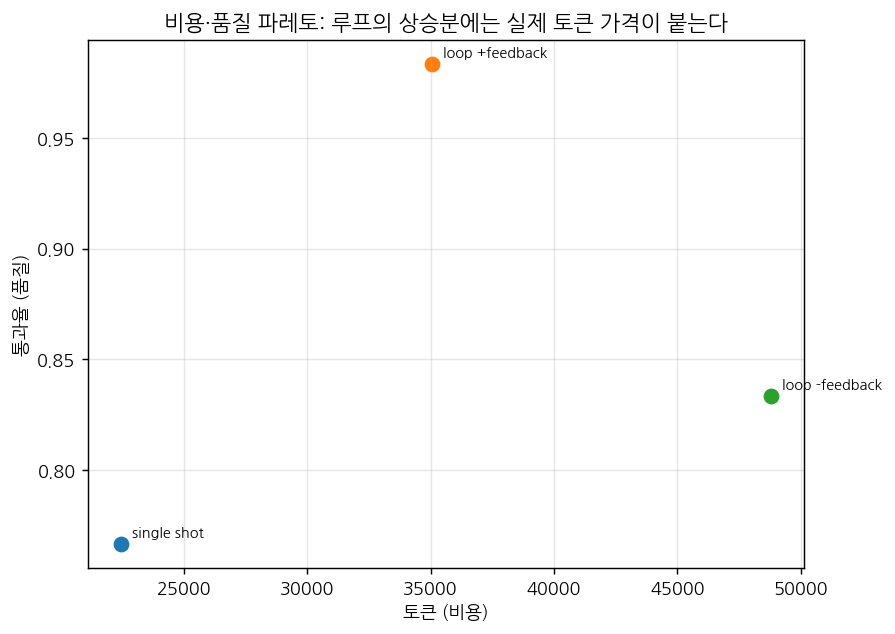

  saved + displayed figure -> /Users/namuai/06-claude/agentic-loop-engineering/agentic-loop-engineering-course-kr/results/figures/08_pareto.png


In [4]:
# ── 3부: 실측 비용·품질 파레토 ────────────────────────────────────
# NB01 이 저장해 둔 metrics 를 그대로 읽는다. 여기서 새로 모델을 돌리지 않는
# 것이 중요하다. 재실행하면 그때의 토큰 수가 되어 NB01 서술과 어긋난다.

m01 = runlog.load_metrics("01_loop")
points = []
if m01:
    tk = m01["tokens"]
    # 세 점 모두 같은 모델·같은 60문제·같은 채점기에서 나왔다. 그래서 두 축의
    # 차이를 전부 '루프 설계' 에 귀속시킬 수 있다.
    points = [
        {"strategy": "single shot", "tokens": tk["baseline"], "quality": m01["baseline_pass_at_1"]},
        {"strategy": "loop +feedback", "tokens": tk["with_feedback"], "quality": m01["final_with_feedback"]},
        {"strategy": "loop -feedback", "tokens": tk["without_feedback"], "quality": m01["final_without_feedback"]},
    ]
    # ⚠️ 함정: quality_per_1k_tokens 만 보고 순위를 매기면 안 된다. 이 지표는
    #    원점을 지나는 직선의 기울기라서 언제나 '가장 싼 점' 을 편든다.
    #    프런티어 위의 어느 점을 고를지는 문제 하나의 값어치가 정한다.
    show.table([{"strategy": p["strategy"], "tokens": p["tokens"], "quality": round(p["quality"], 3),
                 "quality_per_1k_tokens": round(p["quality"] / (p["tokens"] / 1000), 5)} for p in points],
               columns=["strategy", "tokens", "quality", "quality_per_1k_tokens"],
               title="비용 대 품질 (NB01, MBPP+)")
    plotting.scatter_pareto("08_pareto", points, "tokens", "quality", "strategy",
                            "토큰 (비용)", "통과율 (품질)", "비용·품질 파레토: 루프의 상승분에는 실제 토큰 가격이 붙는다")
else:
    show.bullet("NB01 metrics 를 찾지 못했다. NB01 을 먼저 실행한다.")

## 보론 · 자체 호스팅 GPU vs API 손익분기 (한국어판 추가)

여기까지 이 노트북은 토큰을 한 가지 단위로만 셌다. 그런데 같은 토큰이 **어디서 생성되었느냐에 따라 전혀 다른 물건**이 된다.

- 로컬 vLLM 에서 토큰은 **시간**이다. 청구서는 오지 않는다. 대신 GPU 가 점유되고, 다른 실험이 밀리고, 사람이 기다린다. 비용은 있지만 **회계 장부에 나타나지 않는다.**
- API 에서 토큰은 **돈**이다. 기다림은 짧고 GPU 관리 부담도 없다. 대신 **모든 토큰이 그대로 청구서에 찍힌다.**

이 대비가 실무에서 가장 자주 등장하는 질문 하나로 이어진다. **"우리 워크로드는 GPU 를 사는 게 싼가, API 를 쓰는 게 싼가?"**

아래 셀은 그 질문에 이 노트북이 이미 집계한 숫자로 답한다. 시리즈 전체의 실측 토큰을 gpt-5.6-luna 단가로 환산하고, `pricing.breakeven_hours()` 로 **그 금액이 A100 몇 시간치인지**를 낸 다음, 월간 실행 횟수를 늘려 가며 어느 지점에서 자체 호스팅이 API 를 앞지르는지 표로 본다.

세 가지를 미리 말해 둔다.

1. **이 셀은 네트워크를 쓰지 않는다.** 단가표와 이미 집계된 토큰 수만으로 하는 순수 계산이므로, 로컬로 돌렸든 API 로 돌렸든 결과가 같다.
2. **실행 출력이 없는 셀이다.** 직접 실행해야 숫자가 나온다. 그렇게 만든 이유는 단가와 처리량 가정을 각자의 환경 값으로 바꿔 가며 다시 돌려 보라는 뜻이다.
3. **답은 "GPU 가 싸다" 도 "API 가 싸다" 도 아니다.** 답은 언제나 **가동률**이다. 그 사실이 표에서 어떻게 드러나는지 보라.


In [5]:
# ── 보론: 자체 호스팅 GPU vs API 손익분기 (순수 계산, 네트워크 없음) ──
# 이 셀은 모델을 호출하지 않는다. 위에서 집계한 total 과 common.pricing 의
# 단가표만 쓴다. 그래서 vLLM 으로 돌렸든 API 로 돌렸든 결과가 동일하다.
import math

from common import pricing

# 2부에서 집계한 시리즈 전체 토큰. 이 셀만 따로 돌릴 때를 대비해 실측 기본값을 둔다.
TOTAL_TOKENS = int(globals().get("total") or 406_240)

CHAT_MODEL = "gpt-5.6-luna"              # $0.20 / 1M 입력, $1.20 / 1M 출력
EMBED_MODEL = "text-embedding-3-small"   # $0.02 / 1M (임베딩은 출력 토큰이 없다)

# ⚠️ 함정: 런로그에는 '총 토큰' 필드 하나뿐이고 입력/출력 분할이 없다.
#    그런데 출력 단가가 입력의 6배라, 이 비율 하나가 청구서를 몇 배로 흔든다.
#    아래 두 값은 가정이다. 자기 로그에 split 이 있다면 반드시 실측으로 바꾼다.
EMBED_SHARE = 0.15    # 전체 토큰 중 임베딩(04·11번의 코퍼스 인덱싱)이 차지하는 몫
OUTPUT_SHARE = 0.30   # 챗 토큰 중 생성(출력) 토큰의 몫

embed_tokens = int(TOTAL_TOKENS * EMBED_SHARE)
chat_tokens = TOTAL_TOKENS - embed_tokens
out_tokens = int(chat_tokens * OUTPUT_SHARE)
in_tokens = chat_tokens - out_tokens

chat_usd = pricing.cost_usd(CHAT_MODEL, in_tokens, out_tokens) or 0.0
embed_usd = pricing.cost_usd(EMBED_MODEL, embed_tokens, 0) or 0.0
run_usd = chat_usd + embed_usd          # 시리즈 1회 완주분의 API 비용

show.head("자체 호스팅 GPU vs API 손익분기")
show.kv("시리즈 총 토큰", f"{TOTAL_TOKENS:,}")
show.kv("  ├ 챗 입력", f"{in_tokens:,} → {pricing.format_usd(in_tokens / 1e6 * pricing.PRICES[CHAT_MODEL]['input'])}")
show.kv("  ├ 챗 출력", f"{out_tokens:,} → {pricing.format_usd(out_tokens / 1e6 * pricing.PRICES[CHAT_MODEL]['output'])}")
show.kv("  └ 임베딩", f"{embed_tokens:,} → {pricing.format_usd(embed_usd)}")
show.metric("시리즈 1회 API 비용", pricing.format_usd(run_usd))

# ── 이 금액이 GPU 몇 시간치인가 ──────────────────────────────────
# breakeven_hours() 는 'API 청구액 ÷ GPU 시간당 단가' 다. 즉 이 돈으로 살 수 있는
# GPU 시간이다. 실제 실행이 그보다 짧게 끝나면 자체 호스팅이 이긴다.
GPU_HOURLY = pricing.GPU_HOURLY_USD          # A100 80GB 온디맨드 기준 $2.00/h
hours_bought = pricing.breakeven_hours(run_usd, GPU_HOURLY)

# 실제 GPU 점유 시간 추정. 디코딩이 지배하므로 출력 토큰 ÷ 처리량으로 근사한다.
# 프리필과 임베딩 인코딩은 무시했다 → 자체 호스팅에 유리한 쪽으로 기운 낙관치다.
THROUGHPUT_TPS = 400.0    # A100 한 장에서 32B AWQ 모델의 대략적인 출력 토큰/초
hours_used = out_tokens / THROUGHPUT_TPS / 3600.0

show.kv("이 금액으로 살 수 있는 GPU 시간", f"{hours_bought:.4f} h ({hours_bought * 60:.1f} 분)")
show.kv("실제 GPU 점유 추정", f"{hours_used:.4f} h ({hours_used * 60:.1f} 분)")
show.bullet("점유 시간 < 살 수 있는 시간 이면, 실행 중에만 과금하는 온디맨드 GPU 가 API 보다 싸다.")

# ── 월간 실행 횟수를 변수로 둔 손익분기 표 ────────────────────────
# ⚠️ 함정: GPU 비용에는 '유휴 시간' 이 포함된다. 상시 가동 인스턴스는 아무 일도
#    하지 않는 밤과 주말에도 초당 과금된다. 온디맨드 열만 보고 "GPU 가 싸다" 고
#    결론 내는 것이 이 계산에서 가장 흔한 오류다. 상시 가동 열을 함께 봐야 한다.
HOURS_PER_MONTH = 730.0                      # 24 × 365 ÷ 12
always_on_usd = HOURS_PER_MONTH * GPU_HOURLY  # 실행 횟수와 무관한 고정비

rows_be = []
for n in (1, 10, 100, 1_000, 10_000):
    api = run_usd * n
    ondemand = hours_used * n * GPU_HOURLY
    util = hours_used * n / HOURS_PER_MONTH   # 상시 인스턴스였다면의 가동률
    cheapest = min(("API", api), ("온디맨드 GPU", ondemand), ("상시 GPU", always_on_usd),
                   key=lambda t: t[1])[0]
    rows_be.append({
        "월간 실행": f"{n:,}",
        "API": pricing.format_usd(api),
        "온디맨드 GPU": pricing.format_usd(ondemand),
        "상시 GPU": pricing.format_usd(always_on_usd),
        "가동률": f"{util:.1%}" if util <= 1 else f"{util:.1%} (GPU 여러 장 필요)",
        "최저가": cheapest,
    })

show.table(rows_be,
           columns=["월간 실행", "API", "온디맨드 GPU", "상시 GPU", "가동률", "최저가"],
           title="월간 실행 횟수별 비용 (시리즈 1회 = 위 토큰 수 기준)")

# 상시 가동 GPU 가 API 를 앞지르기 시작하는 실행 횟수. 고정비 ÷ 실행당 API 비용.
if run_usd > 0:
    n_breakeven = math.ceil(always_on_usd / run_usd)
    show.metric("상시 가동 GPU 가 API 보다 싸지는 월간 실행 횟수", f"{n_breakeven:,} 회 이상")
    show.kv("그때의 GPU 가동률", f"{hours_used * n_breakeven / HOURS_PER_MONTH:.0%}")
    show.bullet("손익분기의 정체는 가격이 아니라 가동률이다. GPU 를 놀리면 어떤 단가도 이기지 못한다.")
    show.bullet("이 모형에서 온디맨드가 늘 상시보다 싼 것은 유휴 시간을 0 으로 놓았기 때문이다. "
                "실제로는 기동 지연·모델 적재·예약 인스턴스 할인이 이 열의 값을 바꾼다.")
    show.bullet("반대로 상시 포화 상태로 돌릴 워크로드가 있다면 자체 호스팅이 압도적으로 싸진다.")
show.bullet("여기 없는 비용: 엔지니어 시간, 모델 다운로드·업그레이드, 장애 대응, 스토리지, 이그레스.")


====================================== 자체 호스팅 GPU vs API 손익분기 ======================================
  시리즈 총 토큰:                  279,695
    ├ 챗 입력:                  166,419 → $0.03
    ├ 챗 출력:                  71,322 → $0.09
    └ 임베딩:                   41,954 → $0.0008
  시리즈 1회 API 비용                    $0.12
  이 금액으로 살 수 있는 GPU 시간:      0.0599 h (3.6 분)
  실제 GPU 점유 추정:              0.0495 h (3.0 분)
  - 점유 시간 < 살 수 있는 시간 이면, 실행 중에만 과금하는 온디맨드 GPU 가 API 보다 싸다.

-------------------------------- 월간 실행 횟수별 비용 (시리즈 1회 = 위 토큰 수 기준) ---------------------------------
  월간 실행   API       온디맨드 GPU  상시 GPU    가동률    최저가     
  ------  --------  --------  --------  -----  --------
  1       $0.12     $0.10     $1460.00  0.0%   온디맨드 GPU
  10      $1.20     $0.99     $1460.00  0.1%   온디맨드 GPU
  100     $11.97    $9.91     $1460.00  0.7%   온디맨드 GPU
  1,000   $119.71   $99.06    $1460.00  6.8%   온디맨드 GPU
  10,000  $1197.09  $990.58   $1460.00  67.8%  온디맨드 GPU
  상시 가동 GPU 가 API 보다 싸지는 월간 실행 횟수  12,1

## 이 실행이 실제로 보여 준 것


In [6]:
show.head("이 실행이 실제로 보여 준 것")

# ⚠️ 함정: 결론 문장을 하드코딩하지 않고 실측 point 에서 계산한다. 다른 모델이나
#    다른 표본에서 배수가 달라지면 이 셀은 그 사실을 그대로 말해야 한다.
if points:
    base = points[0]
    fb = points[1]
    extra = fb["tokens"] - base["tokens"]      # 루프가 추가로 쓴 토큰
    lift = fb["quality"] - base["quality"]     # 그 대가로 산 품질
    print(f"루프의 +{lift:.1%} 품질 상승에는 추가 토큰 {extra} 개가 들었다 (단발 대비 {fb['tokens']/base['tokens']:.1f}배).")
    print("정확성이 중요한 곳이라면 낼 만한 값이다. 다만 고빈도로 돌리면 이 배수가 그대로")
    print("곱해지고, 그래서 예산 가드(조기 종료)와 시도 상한이 필수가 된다.")
print(f"이 시리즈는 총 {total} 토큰을 {len(log)} 회 실행에 걸쳐 기록했고, 전부 런로그에서 추적된다.")


========================================= 이 실행이 실제로 보여 준 것 =========================================
루프의 +21.7% 품질 상승에는 추가 토큰 12623 개가 들었다 (단발 대비 1.6배).
정확성이 중요한 곳이라면 낼 만한 값이다. 다만 고빈도로 돌리면 이 배수가 그대로
곱해지고, 그래서 예산 가드(조기 종료)와 시도 상한이 필수가 된다.
이 시리즈는 총 279695 토큰을 9 회 실행에 걸쳐 기록했고, 전부 런로그에서 추적된다.
